Neighbors within eps=0.55 for new point [1.  3.5]: 18
Classification of new point: Core point (belongs to a cluster)


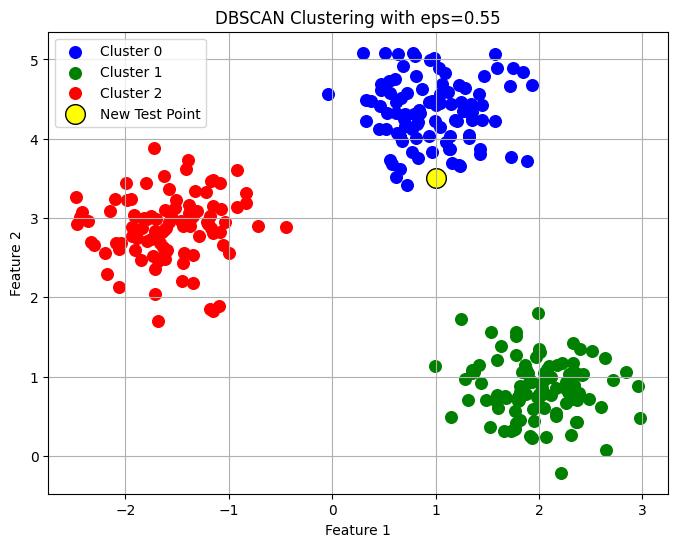

'Output -\nNeighbors within eps=0.55 for new point [1.  3.5]: 18\nClassification of new point: Core point (belongs to a cluster)\n'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
# Step 1: Generate synthetic dataset
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.4, random_state=0)
# Step 2: Fit DBSCAN
eps = 0.55
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X)
# Step 3: New test point
new_point = np.array([[1, 3.5]])
# Step 4: Manually determine if it's core/border/noise
# Compute distances from new_point to all training points
distances = np.linalg.norm(X - new_point, axis=1)
# Count how many points are within eps distance
neighbors_within_eps = np.sum(distances < eps)
print(f"Neighbors within eps={eps} for new point {new_point[0]}: {neighbors_within_eps}")
if neighbors_within_eps >= min_samples:
   classification = "Core point (belongs to a cluster)"
elif neighbors_within_eps > 0:
   classification = "Border point (can belong to a cluster)"
else:
   classification = "Noise (outlier)"
print("Classification of new point:", classification)
# Step 5: Plot
plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = ['blue', 'green', 'red', 'purple']
for label in unique_labels:
   cluster_points = X[labels == label]
   if label == -1:
       plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                   c='black', marker='x', label='Noise', s=70)
   else:
       plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                   c=colors[label % len(colors)], label=f'Cluster {label}', s=70)
# Plot the test point
plt.scatter(new_point[:, 0], new_point[:, 1], c='yellow', edgecolors='black', s=200, label='New Test Point')
plt.title(f"DBSCAN Clustering with eps={eps}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()
'''Output -
Neighbors within eps=0.55 for new point [1.  3.5]: 18
Classification of new point: Core point (belongs to a cluster)
'''